# News Encoder → Survey Expectation Pipeline

**Goal:** Map aggregated FinBERT news embeddings + Shiller macro features to
median survey forecasts (dividend and earnings growth expectations), evaluated
via walk-forward expanding-window cross-validation.

**Stages:**
1. Load news corpus, survey data, and Shiller macro features
2. Encode articles with frozen FinBERT (`ProsusAI/finbert`)
3. Cache P(neutral) scores for sentiment filtering
4. Aggregate embeddings + macro features to quarterly wave vectors
5. Tune Random Forest once via LOO-CV on initial training window
6. Walk-forward evaluation → refit final model → historical extrapolation

**Test mode:** set `TEST_MODE = True` in the config cell to skip hyperparameter
search and use CACHED_PARAMS for fast iteration (~2 min vs ~30 min).

## 1. Setup

In [1]:
#conda update --all

In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm

import torch
from transformers import AutoTokenizer, AutoModel

from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.covariance import LedoitWolf
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    import pandas_datareader.data as web
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "pandas-datareader", "-q"])
    import pandas_datareader.data as web

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device (encoder only — RF runs on CPU)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Encoder device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Encoder device: cuda
GPU: NVIDIA GeForce RTX 2080 Ti


## 2. Configuration

**TODO:** review and tune as needed.

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = Path("./data")
CACHE_DIR  = Path("./cache")
OUTPUT_DIR = Path("./output")
for d in [CACHE_DIR, OUTPUT_DIR]:
    d.mkdir(exist_ok=True, parents=True)

# ── Test mode ─────────────────────────────────────────────────────────────────
# True  → skip LOO-CV, use CACHED_PARAMS below.  Fast iteration (~2 min).
# False → full LOO-CV hyperparameter search.     Production run (~30 min).
TEST_MODE = True

# Paste best_params from tuning_log.csv here after a production run.
CACHED_PARAMS = {
    "dividend_growth": {"neutral_threshold": 1.01, "min_samples_leaf": 3,  "max_features": 0.10},
    "earnings_growth": {"neutral_threshold": 0.75, "min_samples_leaf": 2,  "max_features": 0.05},
}

# ── Encoder ───────────────────────────────────────────────────────────────────
ENCODER_NAME    = "ProsusAI/finbert"
MAX_TOKEN_LEN   = 512
ENCODE_BATCH    = 32

# ── Shiller data ──────────────────────────────────────────────────────────────
SHILLER_XLS = DATA_DIR / "ie_data.xls"

# ── Aggregation ───────────────────────────────────────────────────────────────
AGG_WINDOW_DAYS       = 30
RECENCY_WEIGHTING     = "exponential"
RECENCY_HALFLIFE_DAYS = 7

# ── Sentiment filtering ───────────────────────────────────────────────────────
NEUTRAL_THRESHOLD      = 0.90
NEUTRAL_THRESHOLD_GRID = [0.75, 0.85, 0.90, 0.95, 1.01]
SENTIMENT_BATCH        = 64

# ── Within-wave variance features ─────────────────────────────────────────────
USE_VARIANCE_FEATURES = {
    "dividend_growth": False,
    "earnings_growth": False,
}

# ── Walk-forward evaluation ───────────────────────────────────────────────────
# dividend_growth: 49 waves → 30 initial (19 eval steps)
# earnings_growth: 157 waves → 40 initial (117 eval steps)
MIN_TRAIN_WAVES_PER_SERIES = {
    "dividend_growth": 30,
    "earnings_growth": 40,
}
MIN_TRAIN_WAVES = 40

# ── Random Forest hyperparameter grid ─────────────────────────────────────────
RF_N_ESTIMATORS      = 500
RF_MAX_FEATURES_GRID = ["sqrt", "log2", 0.05, 0.10]
RF_MSL_GRID          = [2, 3, 5, 8, 13, 20, 30]   # floor=2 (leaf=1 overfits at low N)

# ── Shiller macro features ────────────────────────────────────────────────────
# Appended to news embedding vector for each wave.
# All point-in-time at wave closing date — no look-ahead.
SHILLER_FEATURES = [
    "dp_ratio",      # D/P — dividend yield (direct AR1 proxy for div expectations)
    "ep_ratio",      # E/P — earnings yield  (direct AR1 proxy for earn expectations)
    "cape_inv",      # 1/CAPE — cyclically-adjusted earnings yield (NaN pre-1881)
    "gs10",          # 10-year Treasury rate
    "infl_yoy",      # CPI year-on-year inflation
    "real_price_gr", # 12m real price growth
    "div_gr_yoy",    # 12m realised dividend growth (fundamentals-based AR1)
    "earn_gr_yoy",   # 12m realised earnings growth (fundamentals-based AR1)
]

# ── Mahalanobis support check ─────────────────────────────────────────────────
PCA_COMPONENTS_MAHAL = 30

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
import numpy as np, torch
np.random.seed(SEED)
torch.manual_seed(SEED)

## 3. Load News Corpus

**TODO:** plug in your news data here. Expected schema:

| column   | type        | description                              |
|----------|-------------|------------------------------------------|
| `date`   | datetime    | publication date                         |
| `text`   | str         | article body (or headline + lede)        |
| `source` | str (opt.)  | publisher, e.g.\ "WSJ", "FT", "Bloomberg" |

The script below is a placeholder that creates a small dummy DataFrame so you can
verify the pipeline end-to-end before plugging in real data. **Replace this cell**
with your actual data load (CSV, Parquet, SQL, etc.).

In [4]:
# TODO: set the path to your parquet file
NEWS_PARQUET = DATA_DIR / "wsj_headlines_1965_2014_zstd.parquet"   # <-- fill in filename

# TODO: set the column names as they appear in your parquet
NEWS_DATE_COL   = "date"    # column containing article publication date
NEWS_TEXT_COL   = "headline"    # column containing article body / lede
NEWS_SOURCE_COL = None      # column for publisher, or None if absent


def load_news_corpus():
    '''Load news corpus from parquet. Returns DataFrame[date, text].'''
    df = pd.read_parquet(NEWS_PARQUET)

    # Rename to standard column names used downstream
    rename = {NEWS_DATE_COL: "date", NEWS_TEXT_COL: "text"}
    if NEWS_SOURCE_COL:
        rename[NEWS_SOURCE_COL] = "source"
    df = df.rename(columns=rename)[list(rename.values())]

    # Ensure datetime dtype (parquet usually preserves this, but just in case)
    df["date"] = pd.to_datetime(df["date"])

    # Drop rows with missing text or date
    df = df.dropna(subset=["date", "text"]).reset_index(drop=True)

    return df.sort_values("date").reset_index(drop=True)


news_df = load_news_corpus()
print(f"Loaded {len(news_df):,} articles")
print(f"Date range: {news_df['date'].min().date()} → {news_df['date'].max().date()}")
print(f"Columns: {list(news_df.columns)}")
news_df.head()

Loaded 1,449,404 articles
Date range: 1965-01-04 → 2014-12-31
Columns: ['date', 'text']


,date,text
0,1965-01-04,Union Pacific
1,1965-01-04,Abreast of the Market
2,1965-01-04,Dividend News
3,1965-01-04,Ford's Car Sales Set Highs in 1964 And Final Q...
4,1965-01-04,"Technical Measurement Sets Offering of 200,000..."


## 4. Load Survey Data

Two quarterly series loaded from Excel:
- **Dividend growth expectations** — `Dividend_growth_expectations.xlsx`
- **Earnings growth expectations** — `Earnings_growth_expectations.xlsx`

Expected columns: `wave_date` (datetime), `median_forecast` (float).

In [5]:
# TODO: update filenames if yours differ
DIVIDEND_EXCEL = DATA_DIR / "Dividend_growth_expectations.xlsx"
EARNINGS_EXCEL = DATA_DIR / "Earnings_growth_expectations.xlsx"


def make_wave_date(df):
    '''Combine Year + Quarter columns into a datetime (start of quarter).'''
    return pd.to_datetime(
        df["Year"].astype(int).astype(str) + "Q" + df["Quarter"].astype(int).astype(str)
    )


def load_dividend_expectations():
    df = pd.read_excel(DIVIDEND_EXCEL)
    return pd.DataFrame({
        "wave_date":       make_wave_date(df),
        "median_forecast": pd.to_numeric(df["Expected one-year log dividend growth"], errors="coerce"),
    }).dropna().sort_values("wave_date").reset_index(drop=True)


def load_earnings_expectations():
    # Earnings file has a two-row merged header; skip the first header row
    # and use the second row as column names, then take the first denominator
    # variant (current earnings e_t) — columns 2 and 3 (0-indexed after Year/Quarter)
    df = pd.read_excel(EARNINGS_EXCEL, header=[0, 1])

    # year = df.iloc[:,0]
    # quarter = df.iloc[:,1]
    # forecast = df.iloc[:,2]
    # return pd.DataFrame({
    #     "wave_date": pd.to_datetime(year.astype(int).astype(str) + "Q" + quarter.astype(int).astype(str)),
    #     "median_forecast": pd.to_numeric(forecast, errors="coerce"),
    # }).dropna().sort_values("wave_date").reset_index(drop=True)
    # Flatten multi-index columns
    df.columns = [
        " | ".join(str(c).strip() for c in col if "Unnamed" not in str(c)).strip(" | ")
        for col in df.columns
    ]
    # Rename Year/Quarter which land as the first two columns
    df = df.rename(columns={df.columns[0]: "Year", df.columns[1]: "Quarter"})
    # The first earnings variant is the third column
    forecast_col = df.columns[2]
    return pd.DataFrame({
        "wave_date":       make_wave_date(df),
        "median_forecast": pd.to_numeric(df[forecast_col], errors="coerce"),
    }).dropna().sort_values("wave_date").reset_index(drop=True)


# Dict of all survey series — add more here if needed
SURVEY_SERIES = {
    "dividend_growth":  load_dividend_expectations,
    "earnings_growth":  load_earnings_expectations,
}

# Quick preview
for name, loader in SURVEY_SERIES.items():
    df = loader()
    print(f"{name}: {len(df)} waves, "
          f"{df['wave_date'].min().date()} → {df['wave_date'].max().date()}, "
          f"forecast range [{df['median_forecast'].min():.3f}, {df['median_forecast'].max():.3f}]")

dividend_growth: 77 waves, 2003-01-01 → 2022-01-01, forecast range [-0.136, 0.268]
earnings_growth: 185 waves, 1976-01-01 → 2022-01-01, forecast range [-0.081, 1.695]


/tmp/ipykernel_2971572/3697327106.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(
/tmp/ipykernel_2971572/3697327106.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(


## 5. Load Shiller Macro Features

`ie_data.xls` provides monthly S&P 500 price, dividends, earnings, CPI, and
10-year Treasury rate back to 1871 — the only macro source with sufficient
history to cover the full news corpus.

**Features constructed (point-in-time at wave closing date, no look-ahead):**

| Feature | Derivation | Role |
|---|---|---|
| `dp_ratio` | D/P | Dividend yield — direct relevance to dividend expectations |
| `ep_ratio` | E/P | Earnings yield — direct relevance to earnings expectations |
| `cape_inv` | 1/CAPE | Cyclically-adjusted earnings yield (available from 1881) |
| `gs10` | 10y Treasury | Interest rate regime |
| `infl_yoy` | CPI 12m % | Nominal vs real inflation environment |
| `real_price_gr` | (P/CPI) 12m % | Real market momentum |
| `div_gr_yoy` | D 12m % | Realised dividend growth — fundamentals-based AR(1) |
| `earn_gr_yoy` | E 12m % | Realised earnings growth — fundamentals-based AR(1) |

`div_gr_yoy` and `earn_gr_yoy` are the fundamentals-based AR(1) baseline:
the model can condition on what respondents actually observed rather than just
persisting the prior survey wave.

In [6]:
def load_shiller(path=SHILLER_XLS):
    """
    Load Shiller ie_data.xls and construct monthly macro feature table.
    Returns DataFrame with columns: date + SHILLER_FEATURES.
    """
    df = pd.read_excel(path, engine="xlrd", sheet_name="Data", header=7)
    df = df.dropna(subset=["Date"])
    df = df[df["Date"].astype(str).str.match(r"^\d{4}\.\d")].copy()

    # Parse YYYY.MM float → first-of-month datetime
    def parse_date(d):
        d     = float(d)
        year  = int(d)
        month = max(1, min(12, int(round((d - year) * 100))))
        return pd.Timestamp(year=year, month=month, day=1)

    df["date"] = df["Date"].apply(parse_date)
    df = df.sort_values("date").reset_index(drop=True)

    # Core numeric series — forward-fill trailing NaN months
    df["P"]    = pd.to_numeric(df["P"],         errors="coerce").ffill()
    df["D"]    = pd.to_numeric(df["D"],         errors="coerce").ffill()
    df["E"]    = pd.to_numeric(df["E"],         errors="coerce").ffill()
    df["CPI"]  = pd.to_numeric(df["CPI"],       errors="coerce").ffill()
    df["GS10"] = pd.to_numeric(df["Rate GS10"], errors="coerce").ffill()
    df["CAPE"] = pd.to_numeric(df["CAPE"],      errors="coerce")  # NaN pre-1881 OK

    # Feature construction
    df["dp_ratio"]      = df["D"] / df["P"]
    df["ep_ratio"]      = df["E"] / df["P"]
    df["cape_inv"]      = 1.0 / df["CAPE"]           # NaN pre-1881
    df["gs10"]          = df["GS10"]
    df["real_price"]    = df["P"] / df["CPI"]
    df["infl_yoy"]      = df["CPI"].pct_change(12)
    df["real_price_gr"] = df["real_price"].pct_change(12)
    df["div_gr_yoy"]    = df["D"].pct_change(12)
    df["earn_gr_yoy"]   = df["E"].pct_change(12)

    result = df[["date"] + SHILLER_FEATURES].copy()

    print(f"Shiller loaded: {len(result):,} monthly rows  "
          f"({result['date'].min().date()} → {result['date'].max().date()})")
    nulls = result[SHILLER_FEATURES].isna().sum()
    if nulls.any():
        print("  NaN counts (expected for CAPE pre-1881 and growth rates in first year):")
        for feat, cnt in nulls[nulls > 0].items():
            print(f"    {feat:<18s} {cnt:,}")
    return result


def get_shiller_features_for_wave(wave_date, shiller_df):
    """
    Return Shiller feature vector for a wave closing date.
    Uses the most recent monthly observation on or before wave_date.
    Returns np.array of shape (len(SHILLER_FEATURES),); NaN-filled if
    wave_date precedes Shiller coverage.
    """
    available = shiller_df[shiller_df["date"] <= wave_date]
    if available.empty:
        return np.full(len(SHILLER_FEATURES), np.nan)
    return available.iloc[-1][SHILLER_FEATURES].values.astype(np.float64)


shiller_df = load_shiller()

# Quick sanity check on a mid-sample date
_chk = get_shiller_features_for_wave(pd.Timestamp("1990-03-31"), shiller_df)
print("\nSample feature vector (1990-03-31):")
for name, val in zip(SHILLER_FEATURES, _chk):
    print(f"  {name:<18s} {val:.5f}")

Shiller loaded: 1,865 monthly rows  (1871-01-01 → 2026-05-01)
  NaN counts (expected for CAPE pre-1881 and growth rates in first year):
    cape_inv           120
    infl_yoy           12
    real_price_gr      12
    div_gr_yoy         12
    earn_gr_yoy        12

Sample feature vector (1990-03-31):
  dp_ratio           0.03345
  ep_ratio           0.06403
  cape_inv           0.05940
  gs10               8.59000
  infl_yoy           0.05233
  real_price_gr      0.09884
  div_gr_yoy         0.13087
  earn_gr_yoy        -0.13181


## 6. Load FinBERT Encoder

Two objects loaded from the same `ProsusAI/finbert` checkpoint, both frozen:

- **`model`** — `AutoModel`, produces 768-dim CLS embeddings for articles.
- **`sentiment_model`** — `AutoModelForSequenceClassification`, produces
  P(neutral) scores for sentiment filtering. Label order: 0=positive,
  1=negative, 2=neutral.

In [7]:
from transformers import AutoModelForSequenceClassification

print(f"Loading {ENCODER_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(ENCODER_NAME)

model = AutoModel.from_pretrained(ENCODER_NAME).to(DEVICE)
model.eval()
for p in model.parameters():
    p.requires_grad = False

sentiment_model = AutoModelForSequenceClassification.from_pretrained(ENCODER_NAME).to(DEVICE)
sentiment_model.eval()
for p in sentiment_model.parameters():
    p.requires_grad = False

FINBERT_NEUTRAL_IDX = 2   # label order: 0=positive, 1=negative, 2=neutral

print(f"  hidden size  = {model.config.hidden_size}")
print(f"  num labels   = {sentiment_model.config.num_labels}")
print("Both models loaded and frozen.")

Loading ProsusAI/finbert...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: ProsusAI/finbert
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  hidden size  = 768
  num labels   = 3
Both models loaded and frozen.


## 7. Encode Articles & Cache

Articles are batched through FinBERT and the `[CLS]` token from the last
hidden state is saved as the 768-dim document embedding. Both the embeddings
and the corpus-level P(neutral) scores are cached to disk — subsequent runs
load from cache instantly without re-encoding.

In [8]:
def encode_articles_batch(texts, batch_size=ENCODE_BATCH, max_length=MAX_TOKEN_LEN):
    """Encode a list of texts; return (n, 768) float32 array."""
    all_emb = []
    model.eval()
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
        batch  = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=max_length)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad():
            out = model(**inputs)
        cls = out.last_hidden_state[:, 0, :].cpu().numpy().astype(np.float32)
        all_emb.append(cls)
    return np.vstack(all_emb)

In [9]:
# ── Cache article embeddings ──────────────────────────────────────────────────
cache_key  = (f"news_emb_n{len(news_df)}"
              f"_{news_df['date'].min():%Y%m%d}"
              f"_{news_df['date'].max():%Y%m%d}.npy")
cache_path = CACHE_DIR / cache_key

if cache_path.exists():
    print(f"Loading cached embeddings from {cache_path}")
    article_embeddings = np.load(cache_path)
else:
    print(f"Encoding {len(news_df):,} articles...")
    article_embeddings = encode_articles_batch(news_df["text"].tolist())
    np.save(cache_path, article_embeddings)
    print(f"Cached to {cache_path}")

print(f"article_embeddings shape: {article_embeddings.shape}")

# ── Cache P(neutral) scores ───────────────────────────────────────────────────
# Pre-computing once means aggregate_to_waves never runs forward passes —
# all threshold changes are pure numpy indexing.
pneutral_path = CACHE_DIR / cache_key.replace("news_emb", "p_neutral")

if pneutral_path.exists():
    print(f"\nLoading cached P(neutral) from {pneutral_path}")
    p_neutral_all = np.load(pneutral_path)
else:
    print(f"\nComputing P(neutral) for {len(news_df):,} articles...")
    p_neutral_all = get_p_neutral(news_df["text"].tolist())
    np.save(pneutral_path, p_neutral_all)
    print(f"Cached to {pneutral_path}")

print(f"p_neutral_all shape: {p_neutral_all.shape}")
print(f"P(neutral) — mean: {p_neutral_all.mean():.3f}, "
      f">0.90: {(p_neutral_all > 0.80).mean():.1%} of corpus")

Loading cached embeddings from cache/news_emb_n1449404_19650104_20141231.npy
article_embeddings shape: (1449404, 768)

Loading cached P(neutral) from cache/p_neutral_n1449404_19650104_20141231.npy
p_neutral_all shape: (1449404,)
P(neutral) — mean: 0.600, >0.90: 50.6% of corpus


## Pipeline — Random Forest + Walk-Forward Evaluation

**Model:** `RandomForestRegressor` fit on wave vectors of shape
`[768-dim news mean] + [8 Shiller macro features]` = 776 dims.

**Hyperparameter tuning:** joint LOO-CV over `neutral_threshold ×
min_samples_leaf × max_features` on the first `MIN_TRAIN_WAVES` waves.
Skipped in `TEST_MODE` — uses `CACHED_PARAMS` instead.

**Evaluation:** walk-forward expanding window. Each prediction is genuinely
out-of-sample; the AR(1) baseline uses the prior realised survey value.

In [10]:
def recency_weights(article_dates, wave_date, scheme="uniform", halflife_days=7):
    days_back = (wave_date - article_dates).dt.days.values
    if scheme == "uniform":
        return np.ones(len(article_dates))
    return 0.5 ** (days_back / halflife_days)


def get_p_neutral(texts, batch_size=SENTIMENT_BATCH):
    """P(neutral) for a list of texts. Called once at startup to populate cache."""
    out = []
    for i in tqdm(range(0, len(texts), batch_size), desc="P(neutral)"):
        batch  = texts[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors="pt", padding=True,
                           truncation=True, max_length=MAX_TOKEN_LEN)
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
        with torch.no_grad():
            probs = torch.softmax(sentiment_model(**inputs).logits, dim=-1)
            out.append(probs[:, FINBERT_NEUTRAL_IDX].cpu().numpy())
    return np.concatenate(out)


def aggregate_to_waves(news_df, article_embeddings, survey_df,
                       p_neutral_all=None,
                       window_days=AGG_WINDOW_DAYS,
                       scheme=RECENCY_WEIGHTING,
                       halflife=RECENCY_HALFLIFE_DAYS,
                       neutral_threshold=NEUTRAL_THRESHOLD,
                       use_variance=False,
                       shiller_df=None):
    """
    Aggregate articles to one feature vector per survey wave.
    Vector layout: [768 news mean] (+ [768 news std] if use_variance)
                   + [len(SHILLER_FEATURES) macro] if shiller_df provided.
    p_neutral_all: pre-cached corpus array — filtering is pure numpy.
    """
    Z, valid_idx, n_raw_list, n_kept_list = [], [], [], []

    for i, row in survey_df.iterrows():
        wd   = row["wave_date"]
        mask = (
            (news_df["date"] >= wd - pd.Timedelta(days=window_days)) &
            (news_df["date"] <  wd)
        )
        idx = np.where(mask)[0]
        if len(idx) == 0: continue

        emb  = article_embeddings[idx]
        good = ~np.isnan(emb).any(axis=1)
        emb, idx = emb[good], idx[good]
        if len(idx) == 0: continue
        n_raw = len(idx)

        # Sentiment filter — numpy index into pre-cached array
        if p_neutral_all is not None and neutral_threshold < 1.0:
            p_neut = p_neutral_all[idx]
            keep   = p_neut <= neutral_threshold
            if keep.sum() == 0: keep[np.argmin(p_neut)] = True
            emb, idx = emb[keep], idx[keep]
        n_kept = len(idx)

        # Recency-weighted mean
        w      = recency_weights(news_df.iloc[idx]["date"], wd, scheme, halflife)
        w_norm = w / w.sum()
        z_mean = (emb * w_norm[:, None]).sum(axis=0)

        # Optional within-wave variance
        if use_variance and n_kept > 1:
            z_std  = np.sqrt(np.maximum(
                (emb**2 * w_norm[:, None]).sum(0) - z_mean**2, 0.0))
            z_news = np.concatenate([z_mean, z_std])
        elif use_variance:
            z_news = np.concatenate([z_mean, np.zeros_like(z_mean)])
        else:
            z_news = z_mean

        # Shiller macro features
        if shiller_df is not None:
            macro = get_shiller_features_for_wave(wd, shiller_df)
            z_wave = np.concatenate([z_news, macro])
        else:
            z_wave = z_news

        Z.append(z_wave); valid_idx.append(i)
        n_raw_list.append(n_raw); n_kept_list.append(n_kept)

    Z  = np.vstack(Z)
    df = survey_df.iloc[valid_idx].copy().reset_index(drop=True)
    df["n_articles"]     = n_raw_list
    df["n_after_filter"] = n_kept_list
    df["frac_kept"]      = np.array(n_kept_list) / np.array(n_raw_list)
    return Z, df


def tune_rf_loo(Z_train, y_train,
                news_df=None, article_embeddings=None,
                p_neutral_all=None, shiller_df=None,
                survey_slice=None, use_variance=False,
                tune_n_estimators=100):
    """
    Joint LOO-CV over (neutral_threshold, min_samples_leaf, max_features).
    Threshold search re-aggregates using cached p_neutral_all — no forward passes.
    Uses tune_n_estimators=100 (vs 500) for speed during search.
    """
    loo, records = LeaveOneOut(), []
    tune_thresh  = p_neutral_all is not None and survey_slice is not None

    for threshold in tqdm(NEUTRAL_THRESHOLD_GRID if tune_thresh else [NEUTRAL_THRESHOLD],
                          desc="Threshold"):
        Z_t = aggregate_to_waves(
            news_df, article_embeddings, survey_slice,
            p_neutral_all=p_neutral_all, neutral_threshold=threshold,
            use_variance=use_variance, shiller_df=shiller_df,
        )[0] if tune_thresh else Z_train

        for msl in RF_MSL_GRID:
            for mf in RF_MAX_FEATURES_GRID:
                preds = np.empty(len(y_train))
                for tr, va in loo.split(Z_t):
                    m = RandomForestRegressor(n_estimators=tune_n_estimators,
                        min_samples_leaf=msl, max_features=mf,
                        random_state=SEED, n_jobs=-1)
                    m.fit(Z_t[tr], y_train[tr])
                    preds[va] = m.predict(Z_t[va])
                records.append({"neutral_threshold": threshold,
                                "min_samples_leaf": msl,
                                "max_features": mf,
                                "loo_mse": mean_squared_error(y_train, preds)})

    tune_df = pd.DataFrame(records).sort_values("loo_mse").reset_index(drop=True)
    best    = tune_df.iloc[0]
    return {
        "neutral_threshold": float(best["neutral_threshold"]),
        "min_samples_leaf":  int(best["min_samples_leaf"]),
        "max_features":      best["max_features"],
    }, tune_df


def run_pipeline(series_name, survey_loader, news_df, article_embeddings,
                 p_neutral_all=None, shiller_df=None):
    """
    Full pipeline for one survey series.
    TEST_MODE=True skips LOO-CV and uses CACHED_PARAMS.
    """
    print(f"\n{'='*65}")
    print(f"  {series_name}  {'[TEST MODE]' if TEST_MODE else '[PRODUCTION]'}")
    print(f"{'='*65}")

    out_dir  = OUTPUT_DIR / series_name
    out_dir.mkdir(exist_ok=True, parents=True)
    min_train = MIN_TRAIN_WAVES_PER_SERIES.get(series_name, MIN_TRAIN_WAVES)
    use_var   = USE_VARIANCE_FEATURES.get(series_name, False)
    n_macro   = len(SHILLER_FEATURES) if shiller_df is not None else 0
    print(f"Settings: min_train={min_train}, use_variance={use_var}, "
          f"macro_features={n_macro}, feature_dim={(1536 if use_var else 768)+n_macro}")

    survey_df = survey_loader()
    Z_all, waves_df = aggregate_to_waves(
        news_df, article_embeddings, survey_df,
        p_neutral_all=p_neutral_all, neutral_threshold=NEUTRAL_THRESHOLD,
        use_variance=use_var, shiller_df=shiller_df,
    )
    y = waves_df["median_forecast"].values
    n = len(waves_df)
    print(f"Waves: {n}  "
          f"({waves_df['wave_date'].min().date()} → {waves_df['wave_date'].max().date()})")
    print(f"Articles/wave — raw median: {waves_df['n_articles'].median():.0f}, "
          f"kept: {waves_df['n_after_filter'].median():.0f} "
          f"({waves_df['frac_kept'].median():.1%})")

    if n <= min_train:
        raise ValueError(f"Only {n} waves — reduce min_train_waves ({min_train}).")

    # ── Hyperparameter selection ──────────────────────────────────────────────
    if TEST_MODE and series_name in CACHED_PARAMS:
        best_params = CACHED_PARAMS[series_name].copy()
        tune_df     = pd.DataFrame([{**best_params, "loo_mse": float("nan")}])
        print(f"TEST MODE: using cached params: {best_params}")
    else:
        print(f"Tuning on first {min_train} waves (LOO-CV)...")
        survey_init = survey_df.iloc[:min_train].copy().reset_index(drop=True)
        best_params, tune_df = tune_rf_loo(
            Z_train=Z_all[:min_train], y_train=y[:min_train],
            news_df=news_df, article_embeddings=article_embeddings,
            p_neutral_all=p_neutral_all, shiller_df=shiller_df,
            survey_slice=survey_init, use_variance=use_var,
        )
        tune_df.to_csv(out_dir / "tuning_log.csv", index=False)

    print(f"Best params: {best_params}")
    best_threshold = best_params["neutral_threshold"]

    # Re-aggregate at tuned threshold
    Z, waves_df = aggregate_to_waves(
        news_df, article_embeddings, survey_df,
        p_neutral_all=p_neutral_all, neutral_threshold=best_threshold,
        use_variance=use_var, shiller_df=shiller_df,
    )
    y = waves_df["median_forecast"].values
    n = len(waves_df)

    # Impute NaN macro features with calibration-window column means
    if n_macro > 0:
        col_means = np.nanmean(Z[:min_train, -n_macro:], axis=0)
        for j in range(n_macro):
            mask = np.isnan(Z[:, -n_macro + j])
            Z[mask, -n_macro + j] = col_means[j]

    # ── Walk-forward evaluation ───────────────────────────────────────────────
    print(f"\nWalk-forward evaluation ({n - min_train} steps)...")
    wf_records = []
    for t in tqdm(range(min_train, n), desc="Walk-forward"):
        sw = np.log1p(waves_df["n_after_filter"].values[:t])
        sw = sw / sw.mean()
        m  = RandomForestRegressor(
            n_estimators=RF_N_ESTIMATORS,
            min_samples_leaf=best_params["min_samples_leaf"],
            max_features=best_params["max_features"],
            random_state=SEED, n_jobs=-1,
        )
        m.fit(Z[:t], y[:t], sample_weight=sw)
        y_hat = m.predict(Z[t:t+1])[0]
        wf_records.append({
            "wave_date": waves_df.iloc[t]["wave_date"],
            "realized":  float(y[t]), "predicted": float(y_hat),
            "train_size": t, "error": float(y[t] - y_hat),
            "n_articles": int(waves_df.iloc[t]["n_articles"]),
            "n_kept":     int(waves_df.iloc[t]["n_after_filter"]),
        })

    wf_df = pd.DataFrame(wf_records)
    wf_df["sq_error"]     = wf_df["error"] ** 2
    wf_df["ar1_pred"]     = np.concatenate([[y[min_train-1]], wf_df["realized"].values[:-1]])
    wf_df["ar1_sq_error"] = (wf_df["realized"] - wf_df["ar1_pred"]) ** 2

    wf_rmse  = np.sqrt(wf_df["sq_error"].mean())
    ar1_rmse = np.sqrt(wf_df["ar1_sq_error"].mean())
    y_wf     = wf_df["realized"].values
    wf_r2    = 1 - wf_df["sq_error"].sum() / np.sum((y_wf - y_wf.mean())**2)
    dy_true  = np.diff(y_wf)
    dy_pred  = np.diff(wf_df["predicted"].values)
    dir_acc  = np.mean(np.sign(dy_true) == np.sign(dy_pred)) if len(dy_true) > 0 else np.nan

    print(f"\nWalk-forward RMSE — RF: {wf_rmse:.4f}  |  AR(1): {ar1_rmse:.4f}")
    print(f"Walk-forward R²: {wf_r2:.3f}   Directional accuracy: {dir_acc:.1%}")

    # ── Final model on all waves ──────────────────────────────────────────────
    print("\nRefitting final model on all waves...")
    sw_all = np.log1p(waves_df["n_after_filter"].values)
    sw_all = sw_all / sw_all.mean()
    rf_final = RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        min_samples_leaf=best_params["min_samples_leaf"],
        max_features=best_params["max_features"],
        random_state=SEED, n_jobs=-1,
    )
    rf_final.fit(Z, y, sample_weight=sw_all)
    y_ins       = rf_final.predict(Z)
    r2_insample = 1 - np.sum((y - y_ins)**2) / np.sum((y - y.mean())**2)
    print(f"In-sample R² (full fit): {r2_insample:.3f}  "
          f"(use walk-forward R² for honest evaluation)")

    # ── Mahalanobis support check ─────────────────────────────────────────────
    n_mah   = min(PCA_COMPONENTS_MAHAL, len(Z) - 1)
    pca_mah = PCA(n_components=n_mah, random_state=SEED).fit(Z)
    Z_mah   = pca_mah.transform(Z)
    lw      = LedoitWolf().fit(Z_mah)
    mu      = Z_mah.mean(axis=0)
    inv_cov = np.linalg.pinv(lw.covariance_)
    mahal   = lambda z: np.sqrt(np.einsum("ij,jk,ik->i", z-mu, inv_cov, z-mu))
    thresh  = np.quantile(mahal(Z_mah), 0.99)
    wf_df["mahal_dist"]     = mahal(pca_mah.transform(Z[min_train:]))
    wf_df["out_of_support"] = wf_df["mahal_dist"] > thresh

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    title = f"{series_name.replace('_',' ').title()}"
    if TEST_MODE: title += "  [test mode]"
    fig.suptitle(title, fontweight="bold")

    ax = axes[0]
    ax.scatter(wf_df["realized"], wf_df["predicted"], alpha=0.7, color="C0")
    lo, hi = min(wf_df["realized"].min(), wf_df["predicted"].min()),              max(wf_df["realized"].max(), wf_df["predicted"].max())
    ax.plot([lo,hi],[lo,hi],"k--",lw=1)
    ax.set_xlabel("Realized"); ax.set_ylabel("Predicted")
    ax.set_title("Walk-forward: predicted vs. realized"); ax.grid(alpha=0.3)
    ax.text(0.05,0.92,f"R²={wf_r2:.3f}  RMSE={wf_rmse:.4f}",
            transform=ax.transAxes,fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3",fc="white",alpha=0.8))

    ax = axes[1]
    ax.plot(waves_df["wave_date"].values[:min_train], y[:min_train],
            "-", color="gray", alpha=0.4, label="Tuning window")
    ax.plot(wf_df["wave_date"], wf_df["realized"],  "-",  color="C0", label="Realized")
    ax.plot(wf_df["wave_date"], wf_df["predicted"], "--", color="C3", label="Predicted (WF)")
    ax.axvline(waves_df["wave_date"].values[min_train], color="gray", ls=":", alpha=0.7)
    ax.set_xlabel("Wave date"); ax.set_ylabel("Forecast")
    ax.set_title("Time series — walk-forward predictions")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    ax = axes[2]
    roll = 8 if n - min_train < 30 else 12
    wf_df["rolling_rmse"]     = wf_df["sq_error"].rolling(roll, min_periods=4).mean().pipe(np.sqrt)
    wf_df["rolling_ar1_rmse"] = wf_df["ar1_sq_error"].rolling(roll, min_periods=4).mean().pipe(np.sqrt)
    ax.plot(wf_df["wave_date"], wf_df["rolling_rmse"],     color="C0",
            label=f"RF ({roll}-step rolling)")
    ax.plot(wf_df["wave_date"], wf_df["rolling_ar1_rmse"], color="C3", ls="--",
            label="AR(1) baseline")
    ax.set_xlabel("Wave date"); ax.set_ylabel("RMSE")
    ax.set_title("Rolling RMSE — RF vs AR(1)")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(out_dir / "walkforward_diagnostics.png", dpi=150, bbox_inches="tight")
    plt.show()

    # ── Save ──────────────────────────────────────────────────────────────────
    wf_df.to_csv(out_dir / "walkforward_predictions.csv", index=False)
    with open(out_dir / "model_final.pkl", "wb") as f:
        pickle.dump({"rf": rf_final, "best_params": best_params,
                     "pca_mah": pca_mah, "ledoit_wolf": lw,
                     "calibration_mean": mu, "support_threshold": thresh,
                     "config": {"series": series_name, "encoder": ENCODER_NAME,
                                "n_waves": int(n), "min_train_waves": min_train,
                                "use_variance": use_var, "n_macro": n_macro,
                                "neutral_threshold": best_threshold,
                                "test_mode": TEST_MODE}}, f)
    print(f"Saved to {out_dir}/")
    return {"series": series_name, "model": rf_final,
            "waves_df": waves_df, "Z": Z, "y": y,
            "wf_df": wf_df, "best_params": best_params, "tune_df": tune_df,
            "wf_rmse": wf_rmse, "ar1_rmse": ar1_rmse,
            "wf_r2": wf_r2, "dir_acc": dir_acc,
            "r2_insample": r2_insample,
            "use_variance": use_var, "min_train": min_train}


  dividend_growth  [TEST MODE]
Settings: min_train=30, use_variance=False, macro_features=8, feature_dim=776


/tmp/ipykernel_2971572/3697327106.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(


Waves: 49  (2003-01-01 → 2015-01-01)
Articles/wave — raw median: 2369, kept: 1724 (73.2%)
TEST MODE: using cached params: {'neutral_threshold': 1.01, 'min_samples_leaf': 3, 'max_features': 0.1}
Best params: {'neutral_threshold': 1.01, 'min_samples_leaf': 3, 'max_features': 0.1}

Walk-forward evaluation (19 steps)...


Walk-forward: 100%|██████████| 19/19 [00:10<00:00,  1.82it/s]



Walk-forward RMSE — RF: 0.0274  |  AR(1): 0.0258
Walk-forward R²: -0.411   Directional accuracy: 55.6%

Refitting final model on all waves...
In-sample R² (full fit): 0.912  (use walk-forward R² for honest evaluation)


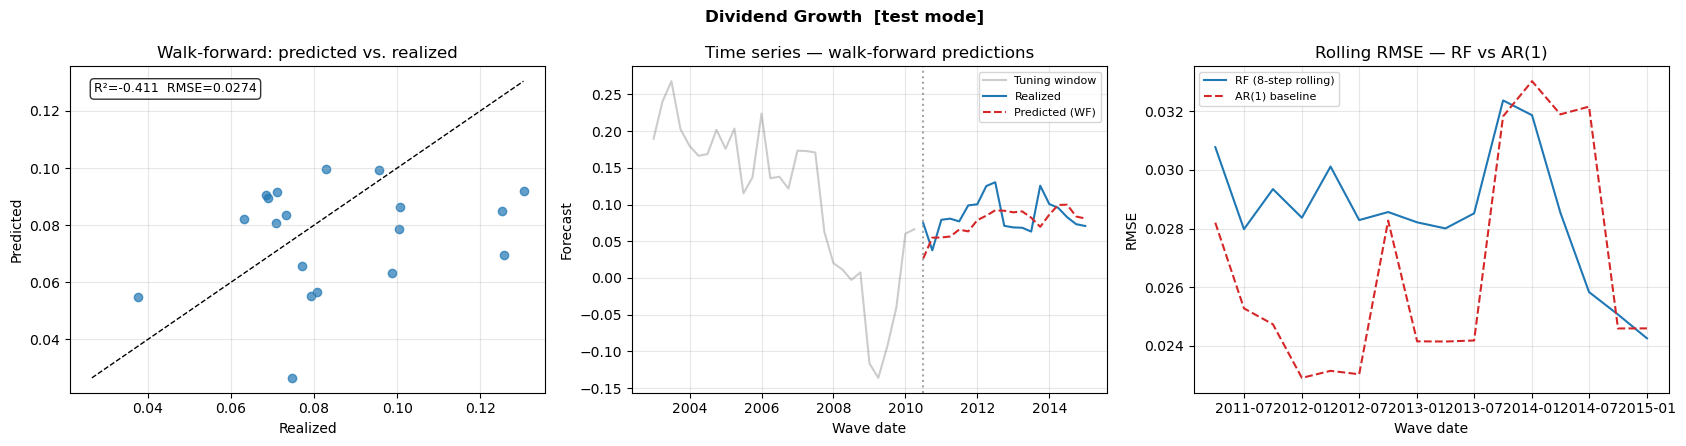

Saved to output/dividend_growth/

  earnings_growth  [TEST MODE]
Settings: min_train=40, use_variance=False, macro_features=8, feature_dim=776


/tmp/ipykernel_2971572/3697327106.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  return pd.to_datetime(


Waves: 157  (1976-01-01 → 2015-01-01)
Articles/wave — raw median: 2311, kept: 1633 (70.9%)
TEST MODE: using cached params: {'neutral_threshold': 0.75, 'min_samples_leaf': 2, 'max_features': 0.05}
Best params: {'neutral_threshold': 0.75, 'min_samples_leaf': 2, 'max_features': 0.05}

Walk-forward evaluation (117 steps)...


Walk-forward: 100%|██████████| 117/117 [01:14<00:00,  1.56it/s]



Walk-forward RMSE — RF: 0.2374  |  AR(1): 0.1361
Walk-forward R²: 0.297   Directional accuracy: 56.0%

Refitting final model on all waves...
In-sample R² (full fit): 0.926  (use walk-forward R² for honest evaluation)


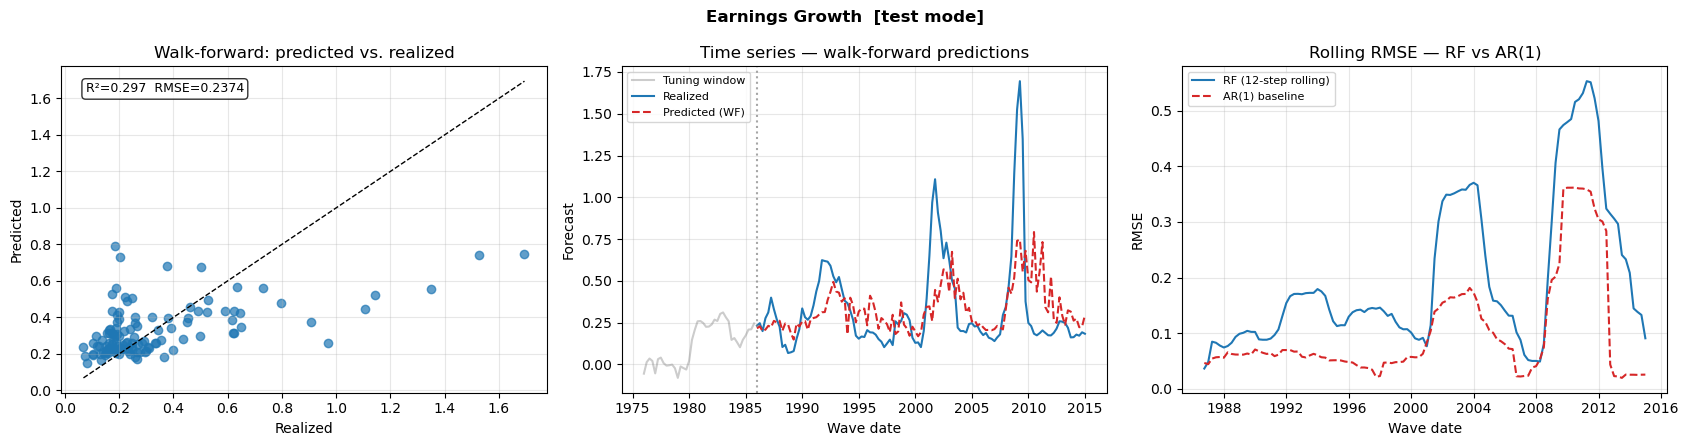

Saved to output/earnings_growth/


In [11]:
all_results = {}
for series_name, loader in SURVEY_SERIES.items():
    all_results[series_name] = run_pipeline(
        series_name, loader, news_df, article_embeddings,
        p_neutral_all=p_neutral_all,
        shiller_df=shiller_df,
    )

In [12]:
print("\n── Walk-Forward Summary ──────────────────────────────────────────────────────────")
print(f"{'Series':<25} {'WF RMSE':>10} {'AR(1)':>8} {'WF R²':>7} "
      f"{'DirAcc':>8} {'thresh':>7} {'msl':>5} {'max_feat':>10}")
print("-" * 90)
for name, res in all_results.items():
    bp = res["best_params"]
    print(f"{name:<25} {res['wf_rmse']:>10.4f} {res['ar1_rmse']:>8.4f} "
          f"{res['wf_r2']:>7.3f} {res['dir_acc']:>7.1%} "
          f"{bp['neutral_threshold']:>7.2f} {bp['min_samples_leaf']:>5} "
          f"{str(bp['max_features']):>10}")
print()
mode_str = "TEST MODE — cached params" if TEST_MODE else "PRODUCTION — full LOO-CV"
print(f"Run mode: {mode_str}")
print("WF RMSE and R² are walk-forward (honest). AR(1) uses prior realised value.")


── Walk-Forward Summary ──────────────────────────────────────────────────────────
Series                       WF RMSE    AR(1)   WF R²   DirAcc  thresh   msl   max_feat
------------------------------------------------------------------------------------------
dividend_growth               0.0274   0.0258  -0.411   55.6%    1.01     3        0.1
earnings_growth               0.2374   0.1361   0.297   56.0%    0.75     2       0.05

Run mode: TEST MODE — cached params
WF RMSE and R² are walk-forward (honest). AR(1) uses prior realised value.


## Signal Decomposition — News vs. Macro

Three Ridge regression variants run on each series using walk-forward evaluation,
reusing the already-aggregated wave vectors from `all_results`:

| Variant | Features | Purpose |
|---|---|---|
| **Macro only** | 8 Shiller features | Sophisticated AR(1) baseline — what macro alone buys |
| **News only** | 768-dim embedding | Pure text signal with no fundamental conditioning |
| **News + Macro** | 776-dim (current) | Full model — incremental value of combining both |

Ridge is used here rather than RF so coefficients are directly interpretable.
The coefficient on `div_gr_yoy` / `earn_gr_yoy` vs the embedding coefficient
norm gives a clean relative contribution measure.

α is chosen by LOO-CV for each variant independently.

In [13]:
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.preprocessing import StandardScaler
import warnings

N_MACRO = len(SHILLER_FEATURES)

def walk_forward_ridge(Z, y, min_train, alphas=None):
    """
    Walk-forward Ridge with LOO-CV alpha selection on initial window.
    Returns wf_df with realized, predicted, sq_error, ar1_sq_error.
    """
    if alphas is None:
        alphas = np.logspace(-4, 6, 60)

    # Tune alpha on initial window using GCV — avoids R²-undefined
    # warning that floods output when LOO holds out a single sample.
    scaler = StandardScaler().fit(Z[:min_train])
    Z_sc   = scaler.transform(Z)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ridge = RidgeCV(alphas=alphas, scoring="neg_mean_squared_error",
                        gcv_mode="auto")
        ridge.fit(Z_sc[:min_train], y[:min_train])
    best_alpha = ridge.alpha_

    # Walk-forward loop — plain Ridge at fixed alpha, no per-fold CV
    records = []
    for t in range(min_train, len(y)):
        sc_t  = StandardScaler().fit(Z[:t])
        Z_tr  = sc_t.transform(Z[:t])
        Z_va  = sc_t.transform(Z[t:t+1])
        m     = Ridge(alpha=best_alpha)
        m.fit(Z_tr, y[:t])
        records.append({
            "realized":  float(y[t]),
            "predicted": float(m.predict(Z_va)[0]),
        })

    wf = pd.DataFrame(records)
    wf["error"]         = wf["realized"] - wf["predicted"]
    wf["sq_error"]      = wf["error"] ** 2
    wf["ar1_pred"]      = np.concatenate([[y[min_train-1]], wf["realized"].values[:-1]])
    wf["ar1_sq_error"]  = (wf["realized"] - wf["ar1_pred"]) ** 2

    rmse     = np.sqrt(wf["sq_error"].mean())
    ar1_rmse = np.sqrt(wf["ar1_sq_error"].mean())
    y_wf     = wf["realized"].values
    r2       = 1 - wf["sq_error"].sum() / np.sum((y_wf - y_wf.mean())**2)
    dy_true  = np.diff(y_wf)
    dy_pred  = np.diff(wf["predicted"].values)
    dir_acc  = np.mean(np.sign(dy_true) == np.sign(dy_pred)) if len(dy_true) > 0 else np.nan

    return wf, rmse, ar1_rmse, r2, dir_acc, best_alpha


def get_ridge_coef_summary(Z_full, y, min_train, feature_names, alphas=None):
    """
    Fit Ridge on full calibration set and return signed coefficients.
    Used for coefficient inspection after walk-forward evaluation.
    """
    if alphas is None:
        alphas = np.logspace(-4, 6, 60)
    scaler = StandardScaler().fit(Z_full[:min_train])
    Z_sc   = scaler.transform(Z_full)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        ridge = RidgeCV(alphas=alphas, scoring="neg_mean_squared_error",
                        gcv_mode="auto")
        ridge.fit(Z_sc, y)
    coef   = ridge.coef_
    return pd.Series(coef, index=feature_names), ridge.alpha_


print("Running Ridge decomposition (news only / macro only / news+macro)...")
print("This reuses aggregated wave vectors — no re-encoding needed.\n")

decomp_results = {}

for series_name, res in all_results.items():
    print(f"{'='*55}")
    print(f"  {series_name}")
    print(f"{'='*55}")

    Z_full   = res["Z"]                  # (n_waves, 776) news+macro
    y        = res["y"]
    min_train= res["min_train"]
    n        = len(y)

    # Slice feature groups
    Z_news  = Z_full[:, :-N_MACRO]      # (n, 768) — news embeddings only
    Z_macro = Z_full[:, -N_MACRO:]      # (n, 8)   — Shiller features only

    variants = {
        "macro_only":    Z_macro,
        "news_only":     Z_news,
        "news_and_macro": Z_full,
    }

    series_decomp = {}
    for variant_name, Z_v in variants.items():
        wf, rmse, ar1_rmse, r2, dir_acc, alpha = walk_forward_ridge(
            Z_v, y, min_train
        )
        series_decomp[variant_name] = {
            "wf_df": wf, "rmse": rmse, "ar1_rmse": ar1_rmse,
            "r2": r2, "dir_acc": dir_acc, "alpha": alpha,
            "Z": Z_v,
        }
        print(f"  {variant_name:<18s}  RMSE={rmse:.4f}  AR(1)={ar1_rmse:.4f}  "
              f"R²={r2:.3f}  DirAcc={dir_acc:.1%}  α={alpha:.2e}")

    decomp_results[series_name] = series_decomp
    print()

Running Ridge decomposition (news only / macro only / news+macro)...
This reuses aggregated wave vectors — no re-encoding needed.

  dividend_growth
  macro_only          RMSE=0.0537  AR(1)=0.0258  R²=-4.411  DirAcc=50.0%  α=1.00e-04
  news_only           RMSE=0.0366  AR(1)=0.0258  R²=-1.518  DirAcc=44.4%  α=1.87e+02
  news_and_macro      RMSE=0.0368  AR(1)=0.0258  R²=-1.542  DirAcc=44.4%  α=1.26e+02

  earnings_growth
  macro_only          RMSE=0.1674  AR(1)=0.1361  R²=0.650  DirAcc=59.5%  α=3.63e-01
  news_only           RMSE=0.2295  AR(1)=0.1361  R²=0.343  DirAcc=55.2%  α=8.55e+01
  news_and_macro      RMSE=0.1972  AR(1)=0.1361  R²=0.515  DirAcc=55.2%  α=8.55e+01



In [14]:
# ── Ridge coefficient inspection ──────────────────────────────────────────────
# For the macro-only and news+macro models, inspect which Shiller features
# carry the most weight. The embedding norm is reported as a single number
# for news+macro (768 individual coefs are not interpretable individually).

print("\n── Ridge coefficient inspection (fit on full calibration set) ────────────\n")

for series_name, variants in decomp_results.items():
    print(f"{'='*55}")
    print(f"  {series_name}")
    print(f"{'='*55}")
    min_train = all_results[series_name]["min_train"]
    y         = all_results[series_name]["y"]

    # Macro-only coefficients
    Z_macro = variants["macro_only"]["Z"]
    coef_macro, _ = get_ridge_coef_summary(
        Z_macro, y, min_train, SHILLER_FEATURES
    )
    print("  Macro-only Ridge coefficients (standardised):")
    for feat, val in coef_macro.sort_values(key=abs, ascending=False).items():
        bar = "█" * int(abs(val) / coef_macro.abs().max() * 20)
        sign = "+" if val >= 0 else "-"
        print(f"    {feat:<18s}  {sign}{abs(val):.4f}  {bar}")

    # News+macro: show macro coefs + embedding norm
    Z_full = variants["news_and_macro"]["Z"]
    feat_names = [f"emb_{i}" for i in range(Z_full.shape[1] - N_MACRO)] + SHILLER_FEATURES
    coef_full, _ = get_ridge_coef_summary(Z_full, y, min_train, feat_names)

    emb_coef   = coef_full.iloc[:-N_MACRO].values
    macro_coef = coef_full.iloc[-N_MACRO:]

    emb_norm   = np.linalg.norm(emb_coef)
    macro_norm = np.linalg.norm(macro_coef.values)
    total_norm = emb_norm + macro_norm

    print(f"\n  News+Macro — relative coefficient norms:")
    print(f"    News embedding  ||coef|| = {emb_norm:.4f}  ({emb_norm/total_norm:.1%} of total)")
    print(f"    Macro features  ||coef|| = {macro_norm:.4f}  ({macro_norm/total_norm:.1%} of total)")
    print(f"\n  Macro coefs in News+Macro model:")
    for feat, val in macro_coef.sort_values(key=abs, ascending=False).items():
        bar  = "█" * int(abs(val) / (macro_coef.abs().max() + 1e-9) * 20)
        sign = "+" if val >= 0 else "-"
        print(f"    {feat:<18s}  {sign}{abs(val):.4f}  {bar}")
    print()


── Ridge coefficient inspection (fit on full calibration set) ────────────

  dividend_growth
  Macro-only Ridge coefficients (standardised):
    dp_ratio            -0.1249  ████████████████████
    div_gr_yoy          +0.0437  ██████
    cape_inv            +0.0333  █████
    real_price_gr       -0.0319  █████
    earn_gr_yoy         +0.0206  ███
    infl_yoy            -0.0144  ██
    gs10                +0.0073  █
    ep_ratio            -0.0051  

  News+Macro — relative coefficient norms:
    News embedding  ||coef|| = 0.0269  (79.9% of total)
    Macro features  ||coef|| = 0.0068  (20.1% of total)

  Macro coefs in News+Macro model:
    dp_ratio            -0.0033  ███████████████████
    ep_ratio            +0.0033  ███████████████████
    earn_gr_yoy         +0.0027  ████████████████
    cape_inv            -0.0027  ████████████████
    gs10                +0.0020  ███████████
    real_price_gr       +0.0019  ███████████
    infl_yoy            +0.0011  ██████
    div_gr_yoy 

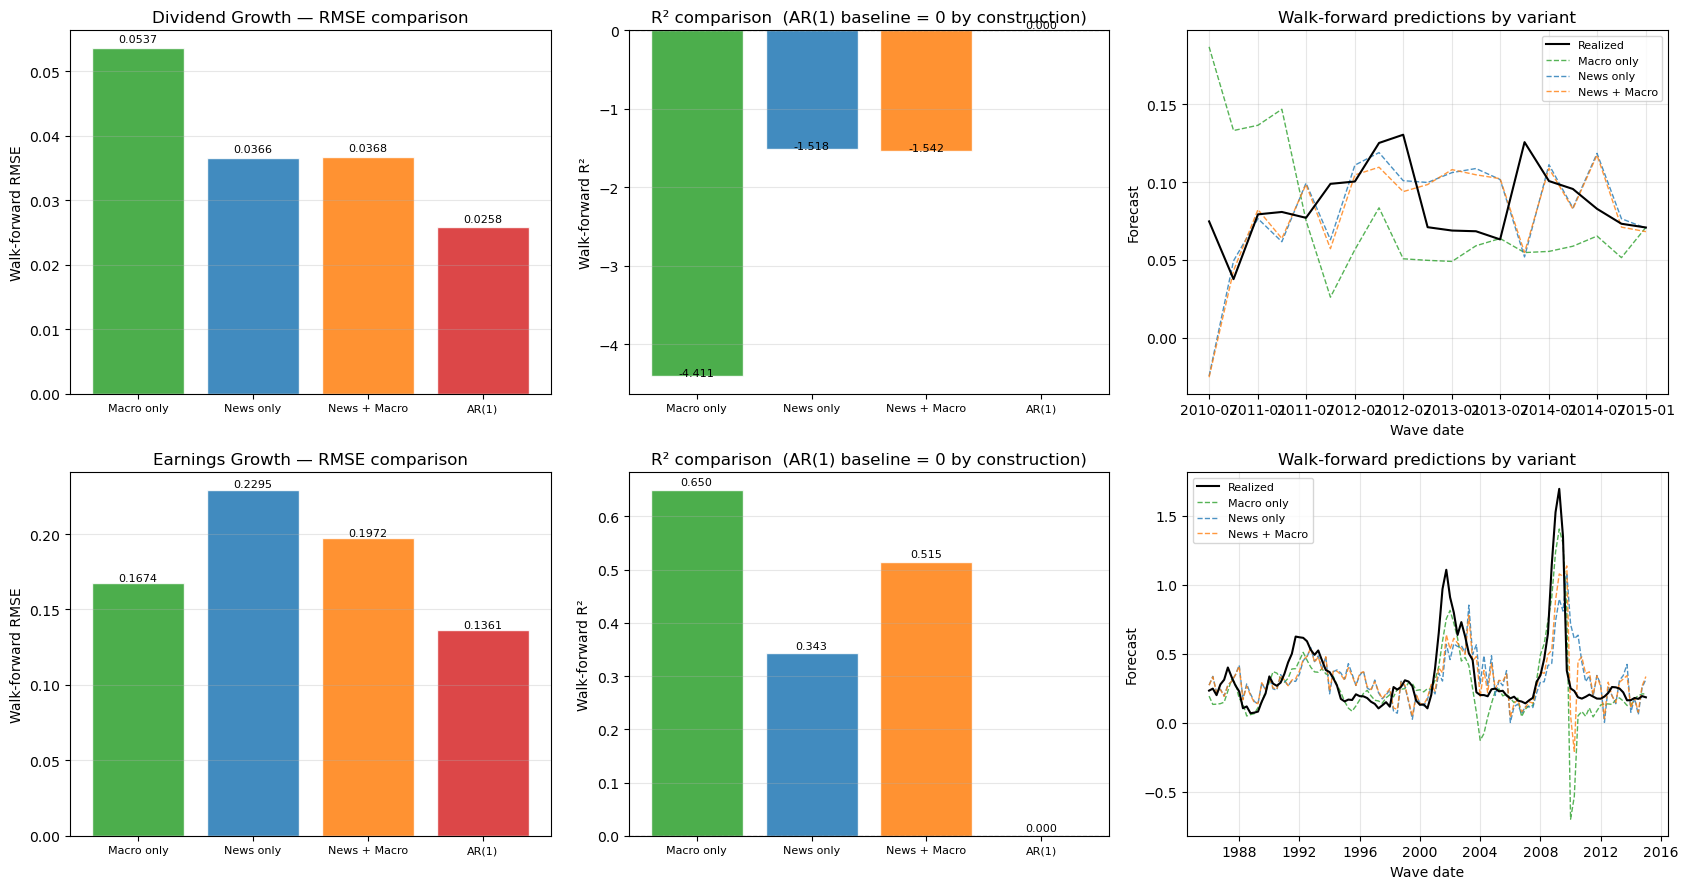

Saved signal_decomposition.png


In [15]:
# ── Comparison plot ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(decomp_results), 3,
                          figsize=(17, 4.5 * len(decomp_results)))
if len(decomp_results) == 1:
    axes = axes[None, :]

variant_labels = {
    "macro_only":     "Macro only",
    "news_only":      "News only",
    "news_and_macro": "News + Macro",
}
variant_colors = {
    "macro_only":     "C2",
    "news_only":      "C0",
    "news_and_macro": "C1",
}

for row, (series_name, variants) in enumerate(decomp_results.items()):
    min_train = all_results[series_name]["min_train"]
    waves_df  = all_results[series_name]["waves_df"]
    y         = all_results[series_name]["y"]
    ar1_rmse  = list(variants.values())[0]["ar1_rmse"]

    # Panel 1: RMSE bar chart
    ax = axes[row, 0]
    names  = list(variant_labels.values()) + ["AR(1)"]
    rmses  = [v["rmse"] for v in variants.values()] + [ar1_rmse]
    colors = [variant_colors[k] for k in variants] + ["C3"]
    bars   = ax.bar(names, rmses, color=colors, alpha=0.85, edgecolor="white")
    ax.set_ylabel("Walk-forward RMSE")
    ax.set_title(f"{series_name.replace('_',' ').title()} — RMSE comparison")
    ax.grid(alpha=0.3, axis="y")
    for bar, val in zip(bars, rmses):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f"{val:.4f}", ha="center", va="bottom", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)

    # Panel 2: R² bar chart
    ax = axes[row, 1]
    r2s    = [v["r2"] for v in variants.values()] + [0.0]
    bars   = ax.bar(names, r2s, color=colors, alpha=0.85, edgecolor="white")
    ax.axhline(0, color="black", lw=0.8, ls="--")
    ax.set_ylabel("Walk-forward R²")
    ax.set_title("R² comparison  (AR(1) baseline = 0 by construction)")
    ax.grid(alpha=0.3, axis="y")
    for bar, val in zip(bars, r2s):
        ypos = bar.get_height() + 0.005 if val >= 0 else bar.get_height() - 0.02
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    ax.tick_params(axis="x", labelsize=8)

    # Panel 3: walk-forward time series for all variants
    ax = axes[row, 2]
    wf_dates = waves_df["wave_date"].values[min_train:]
    ax.plot(wf_dates, y[min_train:], "-", color="black", lw=1.5,
            label="Realized", zorder=5)
    for k, v in variants.items():
        ax.plot(wf_dates, v["wf_df"]["predicted"].values, "--",
                color=variant_colors[k], alpha=0.8, lw=1,
                label=variant_labels[k])
    ax.set_xlabel("Wave date"); ax.set_ylabel("Forecast")
    ax.set_title("Walk-forward predictions by variant")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "signal_decomposition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved signal_decomposition.png")

## Optional: Fine-tuning FinBERT

The pipeline keeps FinBERT frozen. If performance is unsatisfactory, unfreeze
the last 1–2 transformer layers and fine-tune end-to-end with a very small
learning rate (1e-5). See the detailed implementation sketch in the project
documentation PDF. Re-encode and re-cache all article embeddings after any
weight change.

## Historical Extrapolation

**TODO:** With the final model saved in `output/{series}/model_final.pkl`,
call `aggregate_to_waves` on the pre-survey news corpus (same parquet, filtered
to pre-survey dates) with the tuned `neutral_threshold` and `shiller_df`, then
call `rf_final.predict()` on the resulting wave vectors. Flag any waves where
`mahal_dist > support_threshold` as out-of-distribution.